In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Using project root:", PROJECT_ROOT)

import torch
import random
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from mask_unet.models import DebrisClassifier


Using project root: u:\users\beng\Mask_Unet


c:\Users\Crab_workstation\anaconda3\envs\mask_unet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
#image_directory = r'U:/users/debris/data/large_trial_downsample/test'  
image_directory = os.path.join(PROJECT_ROOT, 'debris_data/test/images')
checkpoint_path = os.path.join(PROJECT_ROOT, "models/binary_debris_classifier.pth")


def get_transforms():
    return transforms.Compose([
        transforms.Resize((384, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats, modify as needed
    ])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DebrisClassifier()
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
model.to(device)
model.eval()


transform = get_transforms()


image_files = [f for f in os.listdir(image_directory) if f.endswith(('jpg', 'jpeg', 'png', 'tiff'))]

C:\Users\Crab_workstation\AppData\Local\Temp\ipykernel_11292\2123888715.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path

In [16]:

def display_model_predictions(image_dir, model, transform, device):
    plt.figure(figsize=(12, 12)) 
    
    image_files = os.listdir(image_dir)  # List all images in the directory
    random.shuffle(image_files)

    for i, image_name in enumerate(image_files):
        image_path = os.path.join(image_dir, image_name)
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            prediction = (output.squeeze() > 0.5).cpu().numpy()  # Binary prediction

        # Create a subplot to display the image and its prediction
        plt.subplot(5, 5, i + 1)  # 5x5 grid for 25 images
        plt.imshow(image)
        plt.title(f"{'Debris' if prediction == 1 else 'No Debris'}")
        plt.axis('off')

        if i == 24: 
            break  # Stop after displaying 25 images

    plt.tight_layout()
    plt.show()


In [17]:
device = torch.device("cpu")
model.to(device)
model.eval()

DebrisClassifier(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

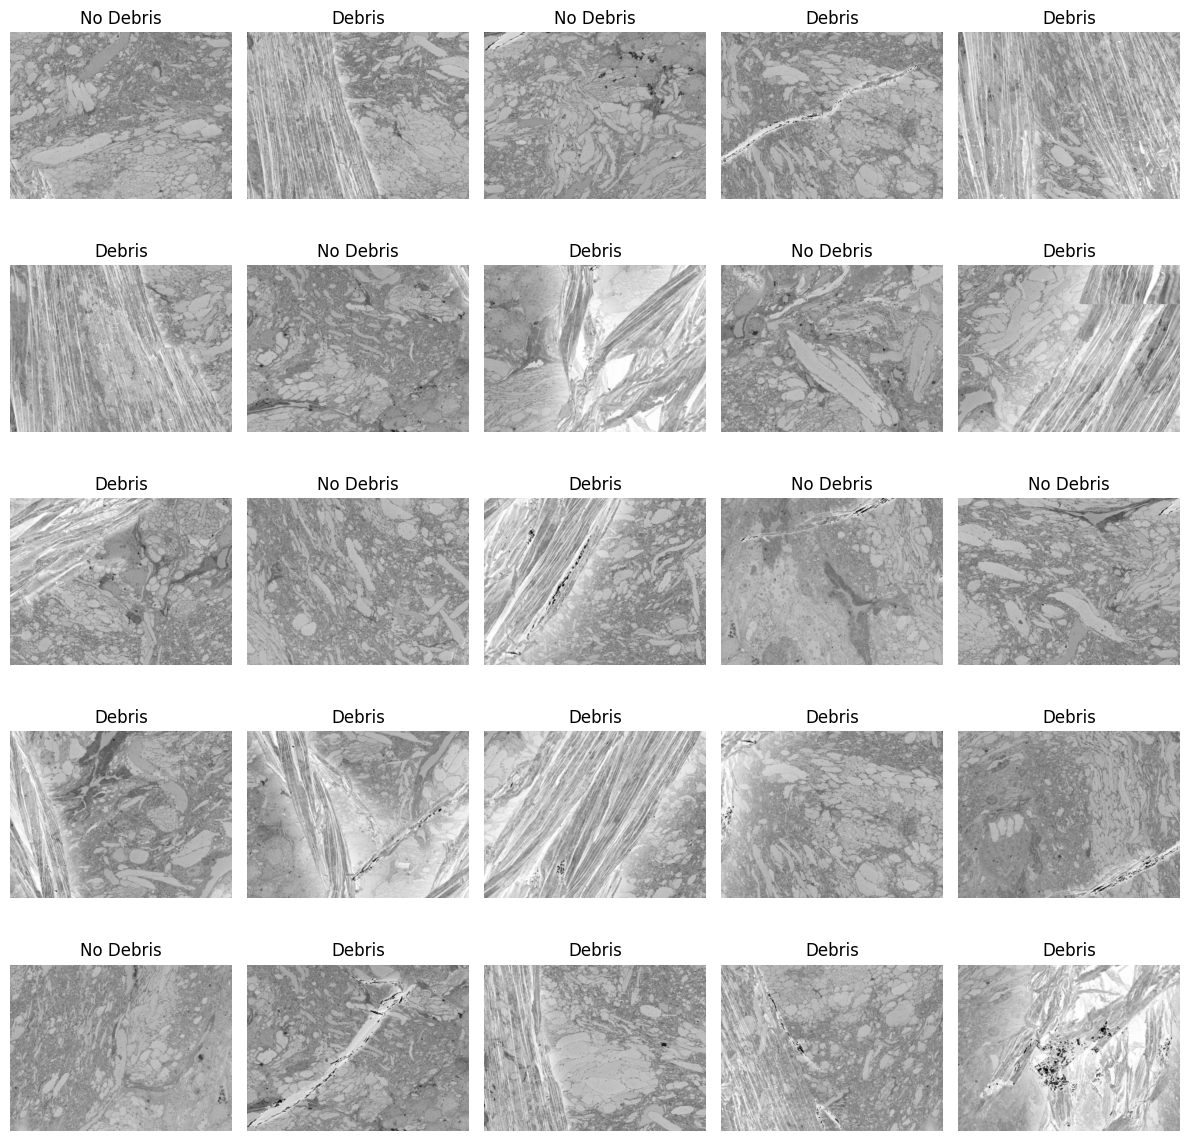

In [18]:
display_model_predictions(image_directory, model, transform, device)